In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data
df = pd.read_csv('../data/raw/rental_data.csv')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (160, 5)

Columns: ['Date', 'County', 'Bedrooms', 'Rent_EUR', 'Property_Type']

First 5 rows:


,Date,County,Bedrooms,Rent_EUR,Property_Type
0,2020-Q1,Dublin,1,1450,Apartment
1,2020-Q1,Dublin,2,1850,Apartment
2,2020-Q1,Dublin,3,2200,House
3,2020-Q1,Cork,1,950,Apartment
4,2020-Q1,Cork,2,1200,Apartment


In [2]:
# Data Cleaning
df['Date'] = df['Date'].astype(str)
df['Year'] = df['Date'].str[:4].astype(int)
df['Quarter'] = df['Date'].str[-2:]

# Check for nulls
print("Null values:\n", df.isnull().sum())

# Check for duplicates
print("\nDuplicates:", df.duplicated().sum())

# Basic stats
print("\nRent Statistics:")
print(df['Rent_EUR'].describe())

# Save cleaned data
df.to_csv('../data/cleaned/rental_cleaned.csv', index=False)
print("\nCleaned data saved ✅")

Null values:
 Date             0
County           0
Bedrooms         0
Rent_EUR         0
Property_Type    0
Year             0
Quarter          0
dtype: int64

Duplicates: 0

Rent Statistics:
count     160.000000
mean     1633.812500
std       591.464308
min       800.000000
25%      1195.000000
50%      1500.000000
75%      1957.500000
max      3500.000000
Name: Rent_EUR, dtype: float64

Cleaned data saved ✅


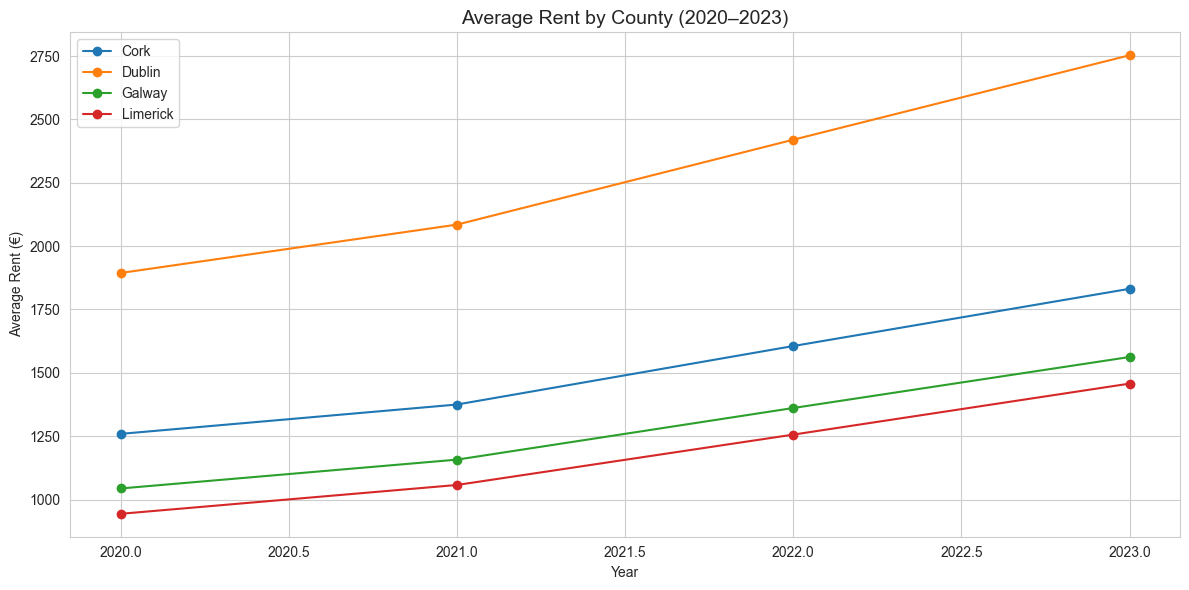

Chart 1 done — rent trends by county


C:\Users\Naveeth Ahamed\AppData\Local\Temp\ipykernel_6972\1008130842.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bedroom_avg, x='Bedrooms', y='Rent_EUR', palette='Blues_d')


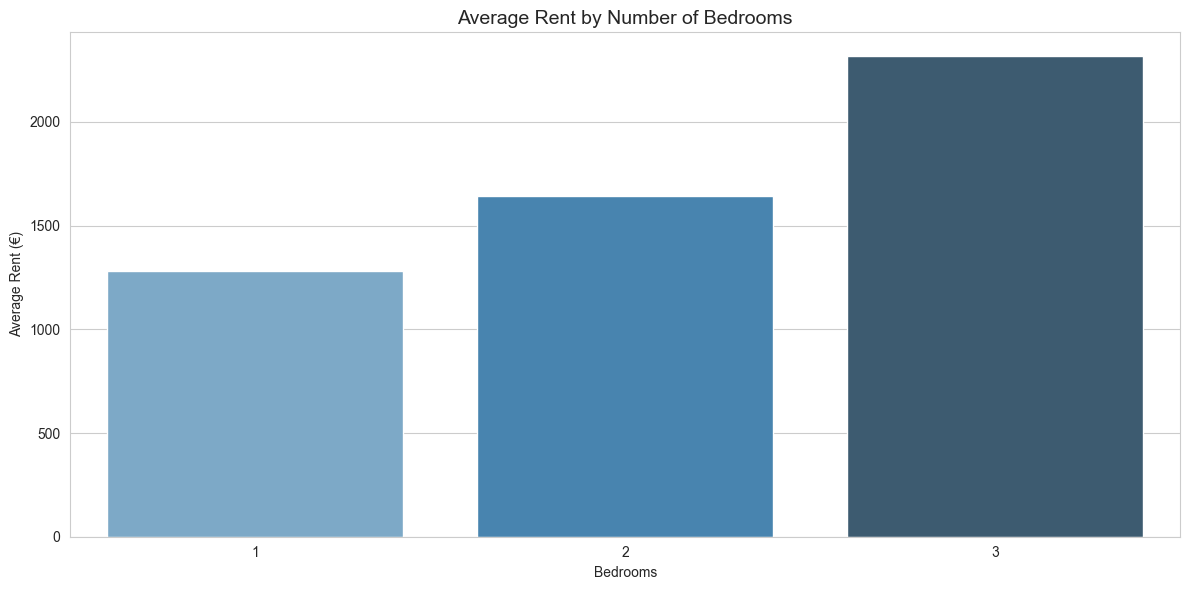

Chart 2 done — bedroom count vs rent


C:\Users\Naveeth Ahamed\AppData\Local\Temp\ipykernel_6972\1008130842.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Property_Type', y='Rent_EUR', palette='Set2')


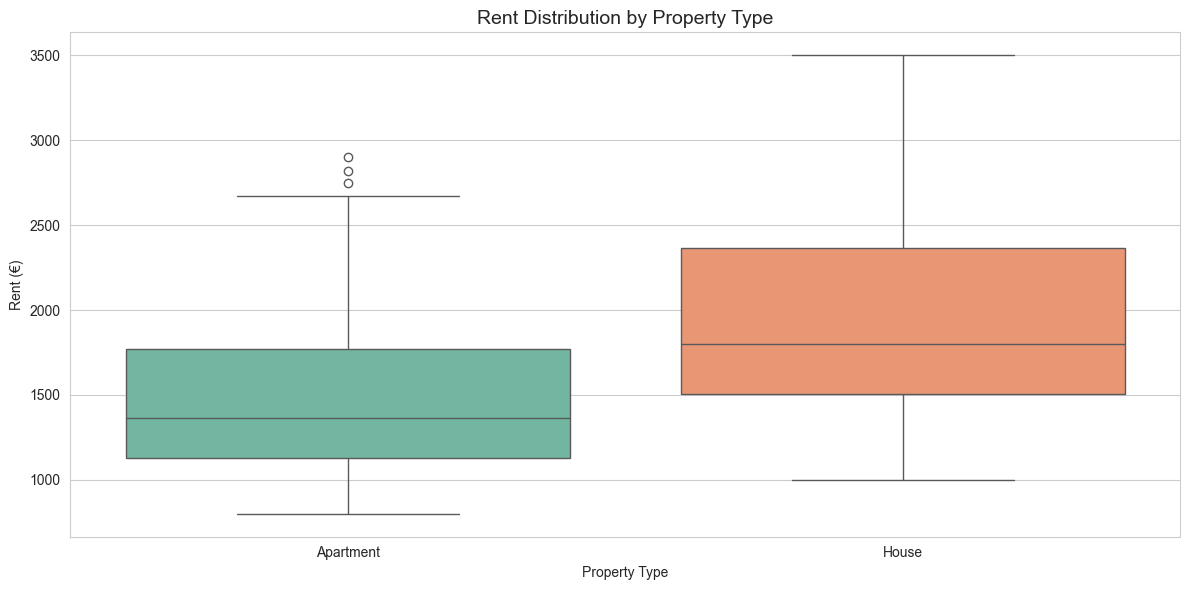

Chart 3 done — apartments vs houses


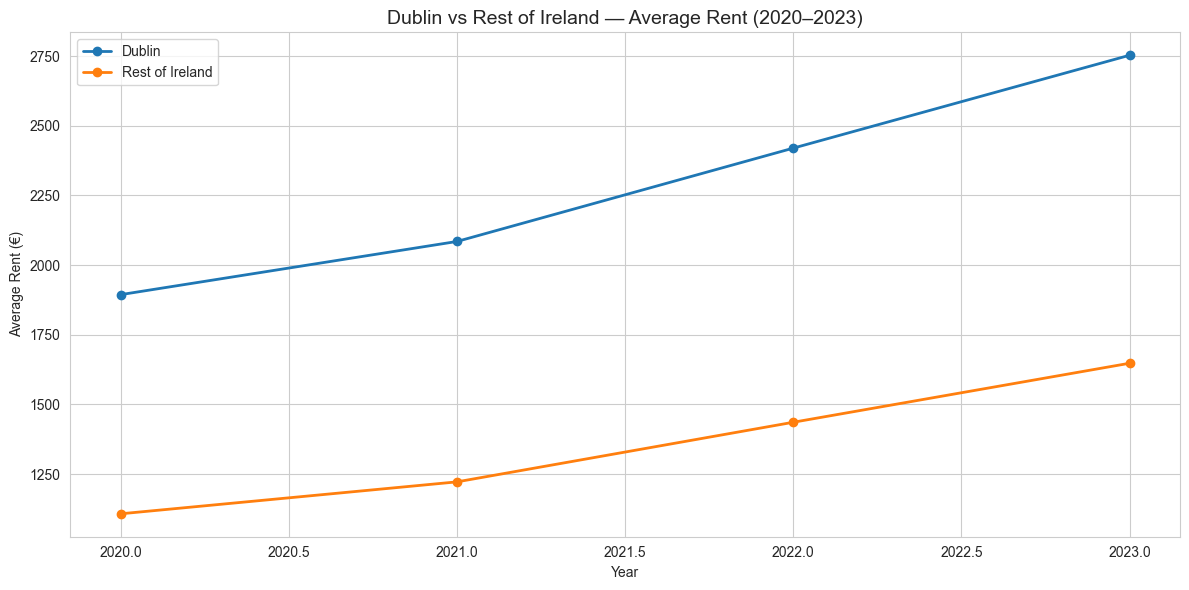

Chart 4 done — Dublin premium confirmed


In [3]:
# Quick style setup — makes charts look clean
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# -------------------------------------------
# Chart 1 — How has rent changed year by year?
# Let's see each county's trend over time
# -------------------------------------------
county_trend = df.groupby(['Year', 'County'])['Rent_EUR'].mean().reset_index()

plt.figure()
for county in county_trend['County'].unique():
    data = county_trend[county_trend['County'] == county]
    plt.plot(data['Year'], data['Rent_EUR'], marker='o', label=county)

plt.title('Average Rent by County (2020–2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Rent (€)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/rent_by_county.png', dpi=150)
plt.show()
print("Chart 1 done — rent trends by county")

# -------------------------------------------
# Chart 2 — Does bedroom count drive rent up?
# Spoiler: yes, but by how much?
# -------------------------------------------
plt.figure()
bedroom_avg = df.groupby('Bedrooms')['Rent_EUR'].mean().reset_index()
sns.barplot(data=bedroom_avg, x='Bedrooms', y='Rent_EUR', palette='Blues_d')
plt.title('Average Rent by Number of Bedrooms', fontsize=14)
plt.xlabel('Bedrooms')
plt.ylabel('Average Rent (€)')
plt.tight_layout()
plt.savefig('../outputs/charts/rent_by_bedrooms.png', dpi=150)
plt.show()
print("Chart 2 done — bedroom count vs rent")

# -------------------------------------------
# Chart 3 — Apartments vs Houses
# Which type costs more and how spread out is it?
# -------------------------------------------
plt.figure()
sns.boxplot(data=df, x='Property_Type', y='Rent_EUR', palette='Set2')
plt.title('Rent Distribution by Property Type', fontsize=14)
plt.xlabel('Property Type')
plt.ylabel('Rent (€)')
plt.tight_layout()
plt.savefig('../outputs/charts/rent_by_property_type.png', dpi=150)
plt.show()
print("Chart 3 done — apartments vs houses")

# -------------------------------------------
# Chart 4 — The Dublin premium
# Everyone knows Dublin is expensive — let's prove it with data
# -------------------------------------------
plt.figure()
df['Region'] = df['County'].apply(lambda x: 'Dublin' if x == 'Dublin' else 'Rest of Ireland')
region_trend = df.groupby(['Year', 'Region'])['Rent_EUR'].mean().reset_index()

for region in region_trend['Region'].unique():
    data = region_trend[region_trend['Region'] == region]
    plt.plot(data['Year'], data['Rent_EUR'], marker='o', label=region, linewidth=2)

plt.title('Dublin vs Rest of Ireland — Average Rent (2020–2023)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Average Rent (€)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/charts/dublin_vs_rest.png', dpi=150)
plt.show()
print("Chart 4 done — Dublin premium confirmed")

In [6]:

# Key Insights Summary
# Pulling out the numbers that tell the story

print("=" * 50)
print("IRISH RENTAL MARKET — KEY INSIGHTS")
print("=" * 50)

# Overall rent growth 2020 to 2023
avg_2020 = df[df['Year'] == 2020]['Rent_EUR'].mean()
avg_2023 = df[df['Year'] == 2023]['Rent_EUR'].mean()
growth = ((avg_2023 - avg_2020) / avg_2020) * 100
print(f"\nOverall rent growth (2020-2023): {growth:.1f}%")

# Most expensive county
most_exp = df.groupby('County')['Rent_EUR'].mean().idxmax()
most_exp_val = df.groupby('County')['Rent_EUR'].mean().max()
print(f"\nMost expensive county: {most_exp} (avg EUR{most_exp_val:.0f}/month)")

# Most affordable county
cheapest = df.groupby('County')['Rent_EUR'].mean().idxmin()
cheapest_val = df.groupby('County')['Rent_EUR'].mean().min()
print(f"\nMost affordable county: {cheapest} (avg EUR{cheapest_val:.0f}/month)")

# Dublin premium
dublin_avg = df[df['County'] == 'Dublin']['Rent_EUR'].mean()
rest_avg = df[df['County'] != 'Dublin']['Rent_EUR'].mean()
premium = ((dublin_avg - rest_avg) / rest_avg) * 100
print(f"\nDublin premium over rest of Ireland: {premium:.1f}%")

# Cheapest option
cheapest_option = df.groupby(['County', 'Bedrooms', 'Property_Type'])['Rent_EUR'].mean().idxmin()
cheapest_rent = df.groupby(['County', 'Bedrooms', 'Property_Type'])['Rent_EUR'].mean().min()
print(f"\nMost affordable option: {cheapest_option[0]}, {cheapest_option[1]} bed {cheapest_option[2]} at EUR{cheapest_rent:.0f}/month")

print("\n" + "=" * 50)

# Save insights to a text file
with open('../outputs/key_insights.txt', 'w') as f:
    f.write("IRISH RENTAL MARKET - KEY INSIGHTS\n")
    f.write("=" * 50 + "\n")
    f.write(f"Overall rent growth (2020-2023): {growth:.1f}%\n")
    f.write(f"Most expensive county: {most_exp} (avg EUR{most_exp_val:.0f}/month)\n")
    f.write(f"Most affordable county: {cheapest} (avg EUR{cheapest_val:.0f}/month)\n")
    f.write(f"Dublin premium over rest of Ireland: {premium:.1f}%\n")

print("Insights saved to outputs/key_insights.txt")

IRISH RENTAL MARKET — KEY INSIGHTS

Overall rent growth (2020-2023): 47.3%

Most expensive county: Dublin (avg EUR2288/month)

Most affordable county: Limerick (avg EUR1179/month)

Dublin premium over rest of Ireland: 69.1%

Most affordable option: Limerick, 1 bed Apartment at EUR1029/month

Insights saved to outputs/key_insights.txt
